## Частина 1. Імпорт бібліотек та завантаження даних

Завдання 1. Імпорт бібліотек

- Імпортуй усі необхідні бібліотеки для роботи з табличними даними та побудови візуалізацій.

In [1]:
# Завдання 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Завдання 2. Завантаження датасету.   
- Завантаж датасет facebook_ads_data.csv.  
- Збережи дані у DataFrame `df`.  
- Відобрази перші рядки таблиці.

In [2]:
# Завдання 2
df=pd.read_csv('facebook_ads_data (2.0).csv')
df["ad_date"] = pd.to_datetime(df["ad_date"])
df.head()

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


## Частина 2. Підготовка щоденної статистики

Завдання 3. Групування даних за датою

Створи таблицю щоденної статистики.

Необхідні результати :    
- Використано групування за `ad_date`.    
- Розраховано сумарні значення:    
`total_spend `   
`total_impressions`    
`total_clicks `   
`total_value `   
- Розраховано показник romi, як відношення `total_value` до `total_spend`.    
- Результат збережено в окремому DataFrame `daily_stats`.

In [3]:
# Завдання 3
daily_stats = df.groupby("ad_date") [["total_spend", "total_impressions", "total_clicks", "total_value"]].sum()
daily_stats["romi"] = daily_stats["total_value"]/daily_stats["total_spend"]
daily_stats

,total_spend,total_impressions,total_clicks,total_value,romi
ad_date,,,,,
2020-11-11,1.89,1800,45,2.38,1.259259
2020-11-12,23.00,10473,397,21.13,0.918696
2020-11-13,6.36,11669,451,9.77,1.536164
2020-11-14,7.27,5005,392,12.67,1.742779
2020-11-15,6.98,12465,657,10.96,1.570201
...,...,...,...,...,...
2022-10-29,714.03,33358,115,680.34,0.952817
2022-10-30,335.91,27562,69,472.61,1.406954
2022-10-31,227.45,6054,58,191.87,0.843570


## Частина 3. Аналіз щоденних витрат на рекламу

Завдання 4. Підготовка даних за 2021 рік

Необхідні результати:   
- Створено окремий DataFrame `daily_stats_2021`.
- DataFrame містить лише записи за 2021 рік.

In [4]:
# Завдання 4
daily_stats_2021 = daily_stats[daily_stats.index.year == 2021]
daily_stats_2021

,total_spend,total_impressions,total_clicks,total_value,romi
ad_date,,,,,
2021-01-01,0.39,353,0,0.59,1.512821
2021-01-02,7.74,10709,205,6.90,0.891473
2021-01-04,70.06,22440,1256,68.47,0.977305
2021-01-05,81.15,60232,1379,61.68,0.760074
2021-01-06,142.77,65265,431,145.97,1.022414
...,...,...,...,...,...
2021-12-27,478.31,103725,504,686.47,1.435199
2021-12-28,359.83,101788,499,450.47,1.251897
2021-12-29,163.25,32290,435,171.76,1.052129


Завдання 5. Графік щоденних витрат

Побудуй лінійний графік щоденних витрат на рекламу.

Необхідні результати :   
- Для побудови графіка використано DataFrame `daily_stats_2021`.   
- Побудовано лінійний графік.   
- На осі X відображається дата.   
- На осі Y відображається total_spend.   
- Графік містить заголовок.  

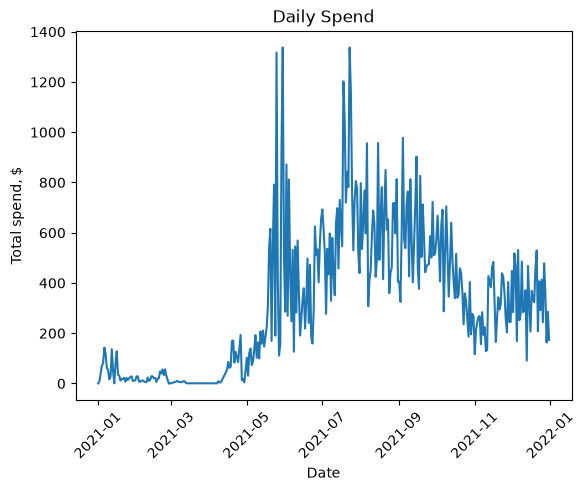

In [5]:
# Завдання 5
plt.plot(daily_stats_2021.index, daily_stats_2021["total_spend"])
plt.title("Daily Spend")
plt.xlabel('Date')
plt.ylabel('Total spend, $')
plt.xticks(rotation=45)
plt.show()

## Частина 4. Аналіз щоденного ROMI

Завдання 6. Графік щоденного ROMI

Побудуй лінійний графік зміни ROMI за днями.

Необхідні результати :    
- Для побудови графіка використано DataFrame `daily_stats_2021`.
- Використовується показник `romi`.   
- Побудовано лінійний графік.   
- На осі X відображається дата.   
- На осі Y відображається ROMI.   
- Графік містить заголовок.   

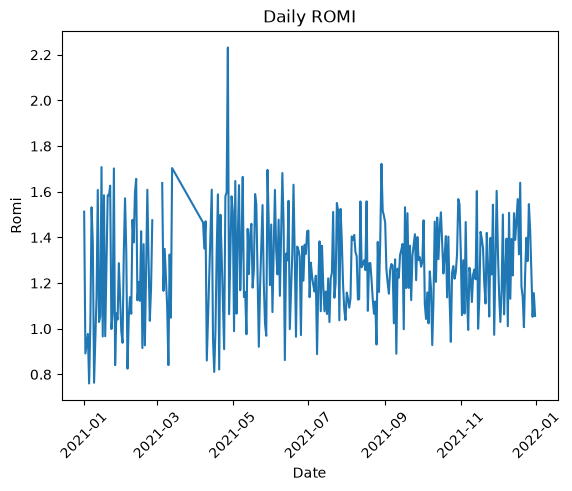

In [6]:
# Завдання 6
plt.plot(daily_stats_2021.index, daily_stats_2021["romi"])
plt.title("Daily ROMI")
plt.xlabel('Date')
plt.ylabel('Romi')
plt.xticks(rotation=45)
plt.show()

## Частина 5. Аналіз рекламних кампаній

Завдання 7. Групування за кампаніями

Створи агреговану таблицю за назвами кампаній.

Необхідні результати :   
- Створи DataFrame `campaign_stats`.   
- Використано групування за campaign_name.    
- Розраховано сумарні значення:    
`total_spend`   
`total_value`

In [7]:
# Завдання 7
campaign_stats = df.groupby("campaign_name") [["total_spend", "total_value"]].sum()
campaign_stats

,total_spend,total_value
campaign_name,,
Brand,539.92,670.15
Crazy discounts,2175.29,2583.59
Discounts,2856.39,3516.27
Electronics,23920.42,29169.38
Expansion,67212.82,83288.66
Hobbies,11326.97,13974.63
Lookalike,63631.09,80234.70
New items,2936.97,3742.05
Promos,4993.84,8793.77


## Частина 6. Візуалізація кампаній

Завдання 8. Графік витрат за кампаніями

Побудуй стовпчиковий графік загальних витрат для кожної кампанії.

Необхідні результати :    
- Використано DataFrame `campaign_stats`.   
- Дані відсортовані за `total_spend` у спадному порядку.    
- Побудовано bar chart.   
- На графіку присутні назви кампаній.   
- Відображено показник `total_spend`.   

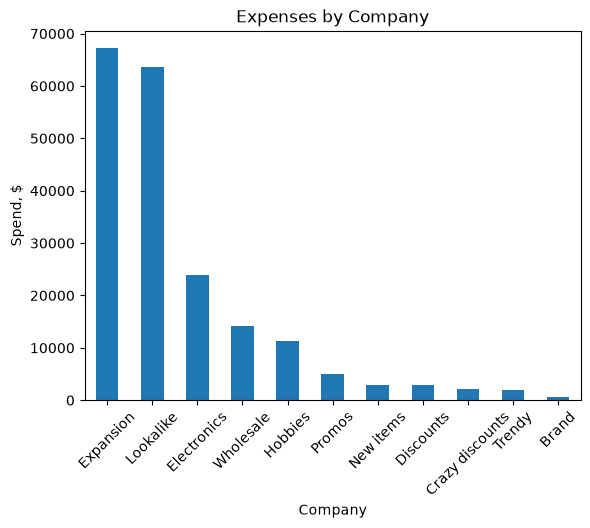

In [8]:
# Завдання 8
campaign_sorted =campaign_stats.sort_values("total_spend", ascending=False)
campaign_sorted["total_spend"].plot(kind="bar")
plt.title("Expenses by Company")
plt.xlabel('Company')
plt.ylabel('Spend, $')
plt.xticks(rotation=45)
plt.show()

Завдання 9. Графік ROMI за кампаніями

Розрахуй ROMI для кожної кампанії та побудуй стовпчиковий графік.

Необхідні результати :  
- Використано DataFrame `campaign_stats`.   
- Створено колонку `romi`.    
- ROMI розраховано як:    
`total_value / total_spend`  
- Дані відсортовані за `romi` у спадному порядку.
- Побудовано bar chart.
- На графіку присутні назви кампаній.
- Відображено показник `romi`.

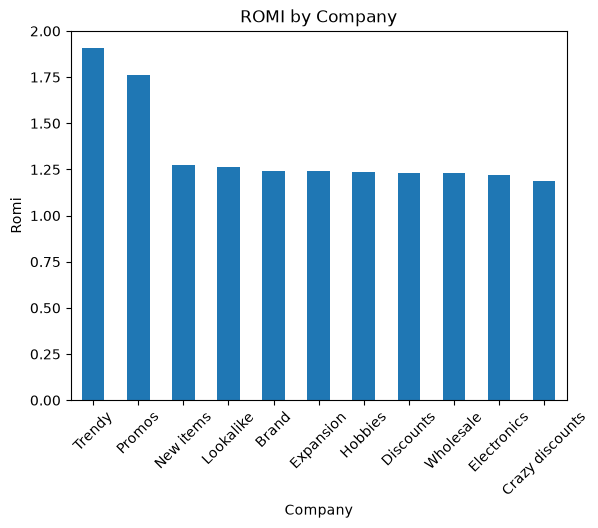

In [9]:
# Завдання 9
campaign_stats["romi"] = campaign_stats["total_value"]/campaign_stats["total_spend"]
campaign_sorted =campaign_stats.sort_values("romi", ascending=False)
campaign_sorted["romi"].plot(kind="bar")
plt.title("ROMI by Company")
plt.xlabel('Company')
plt.ylabel('Romi')
plt.xticks(rotation=45)
plt.show()

## Частина 7. Аналіз розподілів

Завдання 10. Box Plot ROMI по кампаніях

Побудуй box plot для аналізу розкиду значень ROMI у різних кампаніях.

Необхідні результати :
- Використано DataFrame `df`.
- Використано `campaign_name`.
- Використано `romi`.
- Побудовано box plot.  

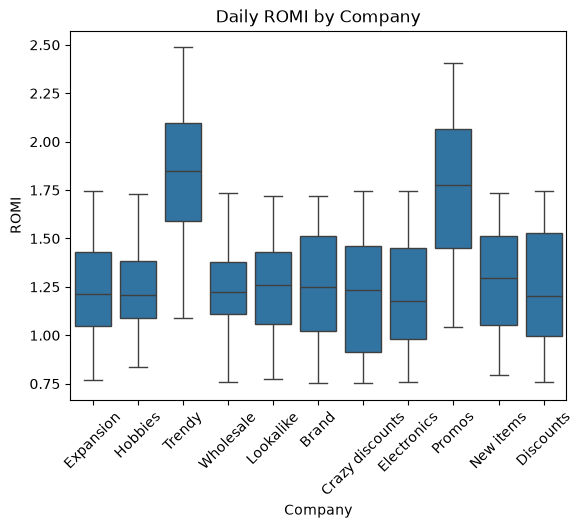

In [10]:
# Завдання 10
sns.boxplot(data=df, x="campaign_name", y="romi")
plt.title("Daily ROMI by Company")
plt.xlabel("Company")
plt.ylabel("ROMI")
plt.xticks(rotation=45)
plt.show()

Завдання 11. Гістограма ROMI

Побудуй гістограму розподілу значень ROMI.

Необхідні результати :
- Використано DataFrame `df`.
- Побудовано гістограму.
- Використовується колонка `romi`.   

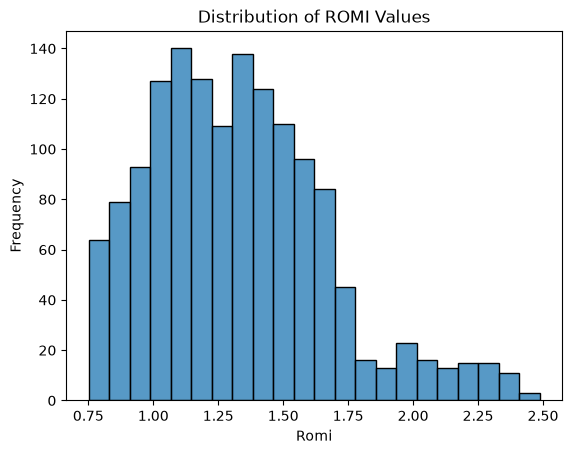

In [11]:
# Завдання 11
sns.histplot(data=df, x="romi")
plt.title("Distribution of ROMI Values")
plt.xlabel('Romi')
plt.ylabel('Frequency')
plt.show()

## Частина 8. Кореляція та регресія

Завдання 12. Теплова карта кореляцій

Побудуй теплову карту кореляції між усіма числовими змінними.

Необхідні результати :     
- Використано DataFrame `df`.
- Розраховано кореляційну матрицю для числових колонок.
- Побудовано heatmap на основі кореляційної матриці.

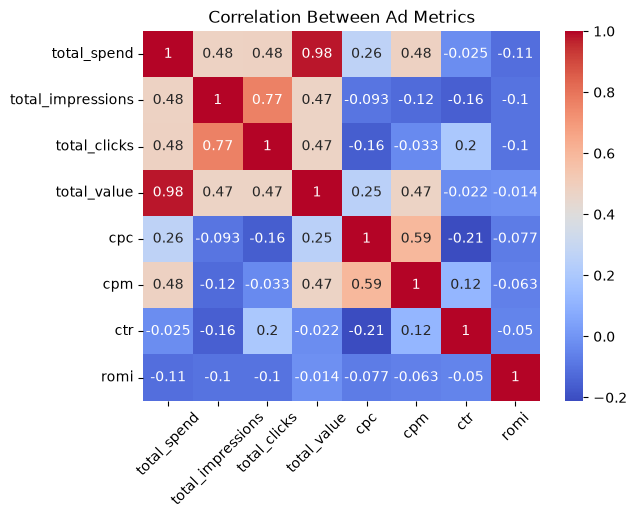

In [12]:
# Завдання 12
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between Ad Metrics")
plt.xticks(rotation=45)
plt.show()

### Завдання 13. Точкова діаграма з лінійною регресією

Побудуй scatter plot з лінією регресії для змінних:  
`total_spend`
`total_value`

Необхідні результати :   
- Використано DataFrame `df`.
- Використано `lmplot()`.
- Використано змінні `total_spend` та `total_value`.
- На графіку присутня регресійна лінія.

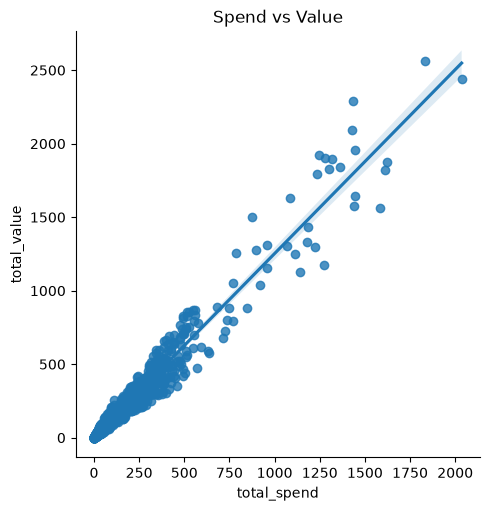

In [13]:
# Завдання 13
sns.lmplot(data=df, x="total_spend", y="total_value")
plt.title('Spend vs Value')
plt.show()